Notebook demonstrating how ODE simulations and linear framework solutions can have similar outputs for the Receptor Memory model

In [1]:
from pysb import Model, Parameter, Compartment, Monomer, Parameter, Rule, Initial, Observable
from pysb.simulator import ScipyOdeSimulator
import numpy as np
import cython
import matplotlib.pyplot as plt
import sympy as sp
import pickle
from collections import Counter
import sys, os
from src.PySBtoLF_func import generate_graphs,adapt_graph_get_rhos
from time import time
from scipy.optimize import least_squares

def func_time(IL10):
    if IL10 > 1e-7:
        return 0.1*5,1e4
    else:
        IL10 = abs(np.log10(IL10)) - 3
        return 10**(IL10)/(1e4)*5,10**(IL10)

We generate a model where RA can stay some time phosphorylated without RB being bound to IL10 (RAp). In this model STAT3 can bound/be phosphorylated by RAp but STAT1 can bound/be phosphorylated only by IL1o+RA+RB complexes. We also generate a model with all interactions to one where repeated complexes (ILRA1=ILRA2) are combined, thus cutting by half the number of edges and nodes

In [2]:
# Model with binding to two IL10RA
def model_func_full(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2','B_t'], {'B_t': ['QB','TB','DB','SB','U']})
    Monomer('RA', ['bA','kA'], {'kA': ['P','U']})
    Monomer('RB', ['bB'])
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    Parameter('K_DEPHOS_R', PA["k_DEPHOS_R"])
    
    # Complexes and reactions (binding of receptors)
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U')
    ILM_free = ILM()
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    # Binding of first receptor
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') % RA(bA=1)
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None)| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RA2_alone = IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') % RA(bA=1)
    Rule('IL_RA2_alone_binding', IL_free + RA(bA=None) | IL_RA2_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=1, bB2=None, B_t='SB') % RB(bB=1)
    Rule('IL_RB1_binding_alone', IL_free + RB(bB=None) | IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
    IL_RB2_alone = IL(bA1=None, bA2=None, bB1=None, bB2=1, B_t='SB') % RB(bB=1)
    Rule('IL_RB2_binding_alone', IL_free + RB(bB=None) | IL_RB2_alone, *[K_IL_RB_f, K_IL_RB_b])
    
    # Binding of second receptor
    IL_noRA1_noRB1_SB = IL(bA1=None, bB1=None, B_t='SB')
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1)
    Rule('IL_RA1_noRB1_binding_DB', IL_noRA1_noRB1_SB + RA(bA=None) | IL_RA1_noRB1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_noRB2_SB = IL(bA2=None, bB2=None, B_t='SB')
    IL_RA2_noRB2_DB = IL(bA2=2, bB2=None, B_t='DB') % RA(bA=2)
    Rule('IL_RA2_noRB1_binding_DB', IL_noRA2_noRB2_SB + RA(bA=None) | IL_RA2_noRB2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_RA1p_RB1_DB = IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1_wRB1_binding_DB', IL_RB1_alone + RA(bA=None,kA='U') >> IL_RA1p_RB1_DB, K_IL_RA2_f)
    Rule('IL_RA1p_wRB1_binding_DB', IL_RB1_alone + RA(bA=None,kA='P') | IL_RA1p_RB1_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA2p_RB2_DB = IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA2_wRB1_binding_DB', IL_RB2_alone + RA(bA=None,kA='U') >> IL_RA2p_RB2_DB, K_IL_RA2_f)
    Rule('IL_RA2p_wRB1_binding_DB', IL_RB2_alone + RA(bA=None,kA='P') | IL_RA2p_RB2_DB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=3, B_t='DB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_DB', IL_noRA1_noRB1_SB + RB(bB=None) | IL_noRA1_RB1_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_noRA2_RB2_DB = IL(bA2=None, bB2=4, B_t='DB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_DB', IL_noRA2_noRB2_SB + RB(bB=None) | IL_noRA2_RB2_DB, *[K_IL_RB2_f, K_IL_RB2_b])
    
    IL_RA1_noRB1_SB = IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') % RA(bA=1,kA='U')
    Rule('IL_wRA1_RB1_binding_DB', IL_RA1_noRB1_SB + RB(bB=None) >> IL_RA1p_RB1_DB, K_IL_RA_RB_f)
    IL_RA1p_noRB1_SB = IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') % RA(bA=1,kA='P')
    Rule('IL_wRA1p_RB1_binding_DB', IL_RA1p_noRB1_SB + RB(bB=None) | IL_RA1p_RB1_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    IL_RA2_noRB2_SB = IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') % RA(bA=1,kA='U')
    Rule('IL_wRA2_RB2_binding_DB', IL_RA2_noRB2_SB + RB(bB=None) >> IL_RA2p_RB2_DB, K_IL_RA_RB_f)
    IL_RA2p_noRB2_SB = IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') % RA(bA=1,kA='P')
    Rule('IL_wRA2p_RB2_binding_DB', IL_RA2p_noRB2_SB + RB(bB=None) | IL_RA2p_RB2_DB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    # Binding of third receptor
    IL_noRA1_noRB1_DB = IL(bA1=None, bB1=None, B_t='DB')
    IL_RA1_noRB1_TB = IL(bA1=1, bB1=None, B_t='TB') % RA(bA=1)
    Rule('IL_RA1_noRB1_binding_TB', IL_noRA1_noRB1_DB + RA(bA=None) | IL_RA1_noRB1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_noRB2_DB = IL(bA2=None, bB2=None, B_t='DB')
    IL_RA2_noRB2_TB = IL(bA2=2, bB2=None, B_t='TB') % RA(bA=2)
    Rule('IL_RA2_noRB1_binding_TB', IL_noRA2_noRB2_DB + RA(bA=None) | IL_RA2_noRB2_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA1_RB1_DB = IL(bA1=None, bB1=1, B_t='DB') % RB(bB=1)
    IL_RA1p_RB1_TB = IL(bA1=1, bB1=2, B_t='TB') % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1_wRB1_binding_TB', IL_noRA1_RB1_DB + RA(bA=None,kA='U') >> IL_RA1p_RB1_TB, K_IL_RA2_f)
    Rule('IL_RA1p_wRB1_binding_TB', IL_noRA1_RB1_DB + RA(bA=None,kA='P') | IL_RA1p_RB1_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_RB2_DB = IL(bA2=None, bB2=1, B_t='DB') % RB(bB=1)
    IL_RA2p_RB2_TB = IL(bA2=1, bB2=2, B_t='TB') % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA2_wRB1_binding_TB', IL_noRA2_RB2_DB + RA(bA=None,kA='U') >> IL_RA2p_RB2_TB, K_IL_RA2_f)
    Rule('IL_RA2p_wRB1_binding_TB', IL_noRA2_RB2_DB + RA(bA=None,kA='P') | IL_RA2p_RB2_TB, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_noRA1_RB1_TB = IL(bA1=None, bB1=3, B_t='TB') % RB(bB=3)
    Rule('IL_noRA1_RB1_binding_TB', IL_noRA1_noRB1_DB + RB(bB=None) | IL_noRA1_RB1_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    IL_noRA2_RB2_TB = IL(bA2=None, bB2=4, B_t='TB') % RB(bB=4)
    Rule('IL_noRA2_RB2_binding_TB', IL_noRA2_noRB2_DB + RB(bB=None) | IL_noRA2_RB2_TB, *[K_IL_RB2_f, K_IL_RB2_b])
    
    IL_RA1_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1,kA='U')
    Rule('IL_wRA1_RB1_binding_TB', IL_RA1_noRB1_DB + RB(bB=None) >> IL_RA1p_RB1_TB, K_IL_RA_RB_f)
    IL_RA1p_noRB1_DB = IL(bA1=1, bB1=None, B_t='DB') % RA(bA=1,kA='P')
    Rule('IL_wRA1p_RB1_binding_TB', IL_RA1p_noRB1_DB + RB(bB=None) | IL_RA1p_RB1_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    IL_RA2_noRB2_DB = IL(bA2=1, bB2=None, B_t='DB') % RA(bA=1,kA='U')
    Rule('IL_wRA2_RB2_binding_TB', IL_RA2_noRB2_DB + RB(bB=None) >> IL_RA2p_RB2_TB, K_IL_RA_RB_f)
    IL_RA2p_noRB2_DB = IL(bA2=1, bB2=None, B_t='DB') % RA(bA=1,kA='P')
    Rule('IL_wRA2p_RB2_binding_TB', IL_RA2p_noRB2_DB + RB(bB=None) | IL_RA2p_RB2_TB, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    # Binding of fourth receptor
    IL_noRA1_TB = IL(bA1=None, bA2=2, bB1=3, bB2=4, B_t='TB') % RA(bA=2,kA='P') % RB(bB=3) % RB(bB=4)
    IL_RA1_RA2_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4, B_t='QB') % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=3) % RB(bB=4)
    Rule('IL_RA1_binding_fin', IL_noRA1_TB + RA(bA=None,kA='U') >> IL_RA1_RA2_RB1_RB2, K_IL_RA2_f)
    Rule('IL_RA1p_binding_fin', IL_noRA1_TB + RA(bA=None,kA='P') | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_noRA2_TB = IL(bA1=1, bA2=None, bB1=3, bB2=4, B_t='TB') % RA(bA=1,kA='P') % RB(bB=3) % RB(bB=4)
    Rule('IL_RA2_binding_fin', IL_noRA2_TB + RA(bA=None,kA='U') >> IL_RA1_RA2_RB1_RB2, K_IL_RA2_f)
    Rule('IL_RA2p_binding_fin', IL_noRA2_TB + RA(bA=None,kA='P') | IL_RA1_RA2_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    
    IL_RA1_noRB1_TB = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1,kA='U') % RA(bA=2,kA='P') % RB(bB=4)
    IL_RA1p_noRB1_TB = IL(bA1=1, bA2=2, bB1=None, bB2=4, B_t='TB') % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=4)
    Rule('IL_RA1_RB1_binding_fin', IL_RA1_noRB1_TB + RB(bB=None) >> IL_RA1_RA2_RB1_RB2, K_IL_RA_RB_f)
    Rule('IL_RA1p_RB1_binding_fin', IL_RA1p_noRB1_TB+ RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA2_noRB2_TB = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1,kA='P') % RA(bA=2,kA='U') % RB(bB=3)
    IL_RA2p_noRB2_TB = IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=3)
    Rule('IL_RA2_RB2_binding_fin', IL_RA2_noRB2_TB + RB(bB=None) >> IL_RA1_RA2_RB1_RB2, K_IL_RA_RB_f)
    Rule('IL_RA2p_RB2_binding_fin', IL_RA2p_noRB2_TB + RB(bB=None) | IL_RA1_RA2_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    # Dephosphorylation of receptors
    Rule('RA_DEPHOS', RA(bA=None, kA='P') >> RA(bA=None, kA='U'), K_DEPHOS_R)
    Rule('IL_RA1_DEPHOS', IL(bA1=1,bB1=None) % RA(bA=1, kA='P') >> IL(bA1=1,bB1=None) % RA(bA=1, kA='U'), K_DEPHOS_R)
    Rule('IL_RA2_DEPHOS', IL(bA2=1,bB2=None) % RA(bA=1, kA='P') >> IL(bA2=1,bB2=None) % RA(bA=1, kA='U'), K_DEPHOS_R)
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #ILD_eq, IC["IL0"]*Na*PA["vol_EC"]
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, kA='U') ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None, B_t='U') ** EC)
    
    Observable('RA_free', RA(bA=None, kA='U') ** Cell_PM)
    Observable('RAp_free', RA(bA=None, kA='P') ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, kA='U') ** Cell_PM)
    Observable('IL_RA2', IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, kA='U') ** Cell_PM)
    Observable('IL_RA1p', IL(bA1=1, bA2=None, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, kA='P') ** Cell_PM)
    Observable('IL_RA2p', IL(bA1=None, bA2=1, bB1=None, bB2=None, B_t='SB') ** EC % RA(bA=1, kA='P') ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    Observable('IL_RB2', IL(bA1=None, bA2=None, bB1=None, bB2=1, B_t='SB') ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='U') ** Cell_PM % RA(bA=2, kA='U') ** Cell_PM)
    Observable('IL_RA1p_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RA(bA=2, kA='U') ** Cell_PM)
    Observable('IL_RA1_RA2p', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='U') ** Cell_PM % RA(bA=2, kA='P') ** Cell_PM)
    Observable('IL_RA1p_RA2p', IL(bA1=1, bA2=2, bB1=None, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RA(bA=2, kA='P') ** Cell_PM)
    Observable('IL_RA1p_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, kA='U') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1p_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2_RB1', IL(bA1=None, bA2=1, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='U') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2p_RB1', IL(bA1=None, bA2=1, bB1=2, bB2=None, B_t='DB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA2p_RB2', IL(bA1=None, bA2=1, bB1=None, bB2=2, B_t='DB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2, B_t='DB') ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    
    Observable('IL_RA1p_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RA(bA=2, kA='U') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1p_RA2p_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None, B_t='TB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RA(bA=2, kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1_RA2p_RB2', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1, kA='U') ** Cell_PM % RA(bA=2, kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1p_RA2p_RB2', IL(bA1=1, bA2=2, bB1=None, bB2=3, B_t='TB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RA(bA=2, kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1p_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA2p_RB1_RB2', IL(bA1=None, bA2=1, bB1=2, bB2=3, B_t='TB') ** EC % RA(bA=1, kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    
    Observable('IL_RA1p_RA2p_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1, kA='P') ** Cell_PM % RA(bA=2, kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    Observable('RAp', RA(kA='P') ** Cell_PM)
    
    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf/1,dT/100)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run().all
    return simulator

def model_func_simpl(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2'])
    Monomer('RA', ['bA','kA'], {'kA': ['P','U']})
    Monomer('RB', ['bB']) 
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', 2*PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB_f', 2*PA["k_IL_RB_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RB_b', PA["k_IL_RB_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    Parameter('K_IL_RB2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RB2_b', PA["k_IL_RB_b"])
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    Parameter('K_IL_RA2_2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    Parameter('K_IL_RB2_2_f', PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    
    Parameter('K_IL_RA2_3_b', PA["k_IL_RA_b"]*(1/2))
    Parameter('K_IL_RA_RB_3_b', PA["k_IL_RA_RB_b"]*(1/2))
    
    Parameter('K_IL_RA2_4_b', PA["k_IL_RA_b"]*2)
    Parameter('K_IL_RA_RB_4_b', PA["k_IL_RA_RB_b"]*2)
    
    Parameter('K_DEPHOS_R', PA["k_DEPHOS_R"])
    
    # Complexes and reactions (dimerization of IL) Not added, since the edges regarding dimerization have to be added later (violates LF rules of elements being both in a node and an edge label)
    ILM_free = ILM()
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None)
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    # Complexes and reactions (binding of receptors)
    IL_RA1p_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1,kA='P')
    Rule('IL_RA1p_alone_binding', IL_free + RA(bA=None,kA='P')| IL_RA1p_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1,kA='U')
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None,kA='U')| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RB1_alone = IL(bA1=None, bA2=None, bB1=1, bB2=None) % RB(bB=1)
    Rule('IL_RB1_binding_alone', IL_free + RB(bB=None) | IL_RB1_alone, *[K_IL_RB_f, K_IL_RB_b])
    
    
    # Binding of second receptors from IL-RA1p complex
    IL_RA1p_RA2p = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='P')
    Rule('IL_RA1p_noRA2p_binding_DB', IL_RA1p_alone + RA(bA=None,kA='P') | IL_RA1p_RA2p, *[K_IL_RA2_2_f, K_IL_RA2_b])
    IL_RA1p_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='U')
    Rule('IL_RA1p_noRA2_binding_DB', IL_RA1p_alone + RA(bA=None,kA='U') | IL_RA1p_RA2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1p_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1p_noRB1_binding_DB', IL_RA1p_alone + RB(bB=None) | IL_RA1p_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    IL_RA1p_RB2 = IL(bA1=1, bA2=None, bB1=None, bB2=2) % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1p_noRB2_binding_DB', IL_RA1p_alone + RB(bB=None) | IL_RA1p_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    
    # Binding of second receptors from IL-RA1 complex
    IL_RA1_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1,kA='U') % RA(bA=2,kA='U')
    Rule('IL_RA1_noRA2_binding_DB', IL_RA1_alone + RA(bA=None,kA='U') | IL_RA1_RA2, *[K_IL_RA2_2_f, K_IL_RA2_b])
    Rule('IL_noRA1p_RA2_binding_DB', IL_RA1_alone + RA(bA=None,kA='P') | IL_RA1p_RA2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1p_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1_noRB1_binding_DB', IL_RA1_alone + RB(bB=None) >> IL_RA1p_RB1, K_IL_RA_RB_f)
    IL_RA1_RB2 = IL(bA1=1, bA2=None, bB1=None, bB2=2) % RA(bA=1,kA='U') % RB(bB=2)
    Rule('IL_RA1_noRB2_binding_DB', IL_RA1_alone + RB(bB=None) | IL_RA1_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    
    # Binding of second receptors from IL-RB1 complex
    Rule('IL_noRA1p_RB1_binding_DB', IL_RB1_alone + RA(bA=None,kA='P') | IL_RA1p_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_noRA1_RB1_binding_DB', IL_RB1_alone + RA(bA=None,kA='U') >> IL_RA1p_RB1, K_IL_RA2_f)
    Rule('IL_noRA1p_RB2_binding_DB', IL_RB1_alone + RA(bA=None,kA='P') | IL_RA1p_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_noRA1_RB2_binding_DB', IL_RB1_alone + RA(bA=None,kA='U') | IL_RA1_RB2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RB1_RB2 = IL(bA1=None, bA2=None, bB1=1, bB2=2) % RB(bB=1) % RB(bB=2)
    Rule('IL_RB1_RB2_binding_DB', IL_RB1_alone + RB(bB=None) | IL_RB1_RB2, *[K_IL_RB2_2_f, K_IL_RB2_b])
    
    
    # Binding of third receptors to from IL-RA1p-RA2p-RB1 complex
    IL_RA1p_RA2p_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=3)
    Rule('IL_RA1p_RA2p_noRB1_binding_TB', IL_RA1p_RA2p + RB(bB=None) | IL_RA1p_RA2p_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_3_b])
    Rule('IL_RA1p_RA2_noRB1_binding_TB', IL_RA1p_RA2 + RB(bB=None) >> IL_RA1p_RA2p_RB1, K_IL_RA_RB_f)
    Rule('IL_RA1p_noRA2p_RB1_binding_TB', IL_RA1p_RB1 + RA(bA=None,kA='P') | IL_RA1p_RA2p_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_noRA1p_RA2p_RB1_binding_TB', IL_RA1_RB2 + RA(bA=None,kA='P') | IL_RA1p_RA2p_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_noRA1_RA2p_RB1_binding_TB', IL_RA1_RB2 + RA(bA=None,kA='U') >> IL_RA1p_RA2p_RB1, K_IL_RA2_f)
    
    # Binding of third receptors to from IL-RA1p-RA2-RB1 complex
    IL_RA1p_RA2_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='U') % RB(bB=3)
    Rule('IL_RA1p_RA2_noRB1_binding_TB2', IL_RA1p_RA2 + RB(bB=None) | IL_RA1p_RA2_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RA1_RA2_noRB1_binding_TB', IL_RA1_RA2 + RB(bB=None) >> IL_RA1p_RA2_RB1, K_IL_RA_RB_f)
    Rule('IL_RA1p_noRA2_RB1_binding_TB', IL_RA1p_RB1 + RA(bA=None,kA='U') | IL_RA1p_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_noRA1p_RA2_RB1_binding_TB', IL_RA1_RB2 + RA(bA=None,kA='P') | IL_RA1p_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    Rule('IL_noRA1_RA2_RB1_binding_TB', IL_RA1_RB2 + RA(bA=None,kA='U') >> IL_RA1p_RA2_RB1, K_IL_RA2_f)
    
    # Binding of third receptors to from IL-RA1p-RB1-RB2 complex
    IL_RA1p_RB1_RB2 = IL(bA1=1, bA2=None, bB1=2, bB2=3) % RA(bA=1,kA='P') % RB(bB=2) % RB(bB=3)
    Rule('IL_RA1p_RB1_noRB2_binding_TB', IL_RA1p_RB1 + RB(bB=None) | IL_RA1p_RB1_RB2, *[K_IL_RB2_f, K_IL_RB2_b])
    Rule('IL_RA1p_noRB1_RB2_binding_TB', IL_RA1p_RB2 + RB(bB=None) | IL_RA1p_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RA1_noRB1_RB2_binding_TB', IL_RA1_RB2 + RB(bB=None) >> IL_RA1p_RB1_RB2, K_IL_RA_RB_f)
    Rule('IL_noRA1p_RB1_RB2_binding_TB', IL_RB1_RB2 + RA(bA=None,kA='P') | IL_RA1p_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_3_b])
    Rule('IL_noRA1_RB1_RB2_binding_TB', IL_RB1_RB2 + RA(bA=None,kA='U') >> IL_RA1p_RB1_RB2, K_IL_RA2_f)
    
    
    # Binding of fourth receptor
    IL_RA1p_RA2p_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=3) % RB(bB=4)
    Rule('IL_RA1p_RA2p_RB1_noRB2_binding_QB', IL_RA1p_RA2p_RB1 + RB(bB=None) | IL_RA1p_RA2p_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1p_RA2_RB1_noRB2_binding_QB', IL_RA1p_RA2_RB1 + RB(bB=None) >> IL_RA1p_RA2p_RB1_RB2, K_IL_RA_RB_f)
    Rule('IL_RA1p_noRA2p_RB1_RB2_binding_QB', IL_RA1p_RB1_RB2 + RA(bA=None,kA='P') | IL_RA1p_RA2p_RB1_RB2, *[K_IL_RA2_f, K_IL_RA2_4_b])
    Rule('IL_RA1p_noRA2_RB1_RB2_binding_QB', IL_RA1p_RB1_RB2 + RA(bA=None,kA='U') >> IL_RA1p_RA2p_RB1_RB2, K_IL_RA2_f)
    
    
    # Dephosphorylation of receptors
    Rule('RA_DEPHOS', RA(bA=None, kA='P') >> RA(bA=None, kA='U'), K_DEPHOS_R)
    Rule('IL_RA1p_DEPHOS', IL_RA1p_alone >> IL_RA1_alone, K_DEPHOS_R)
    Rule('IL_RA1p_RA2p_DEPHOS', IL_RA1p_RA2p >> IL_RA1p_RA2, K_DEPHOS_R)
    Rule('IL_RA1p_RA2_DEPHOS', IL_RA1p_RA2 >> IL_RA1_RA2, K_DEPHOS_R)
    Rule('IL_RA1p_RB2_DEPHOS', IL_RA1p_RB2 >> IL_RA1_RB2, K_DEPHOS_R)
    Rule('IL_RA1p_RA2p_RB1_DEPHOS', IL_RA1p_RA2p_RB1 >> IL_RA1p_RA2_RB1, K_DEPHOS_R)
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq) #ILD_eq, IC["IL0"]*Na*PA["vol_EC"]
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, kA='U') ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC)
    Observable('RA_free', RA(bA=None,kA='U') ** Cell_PM)
    Observable('RAp_free', RA(bA=None,kA='P') ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1,kA='U') ** Cell_PM)
    Observable('IL_RA1p', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM)
    Observable('IL_RB1', IL(bA1=None, bA2=None, bB1=1, bB2=None) ** EC % RB(bB=1) ** Cell_PM)
    
    Observable('IL_RA1p_RA2p', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='P') ** Cell_PM)
    Observable('IL_RA1p_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='U') ** Cell_PM)
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1,kA='U') ** Cell_PM % RA(bA=2,kA='U') ** Cell_PM)
    Observable('IL_RA1p_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1p_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2) ** EC % RA(bA=1,kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RA1_RB2', IL(bA1=1, bA2=None, bB1=None, bB2=2) ** EC % RA(bA=1,kA='U') ** Cell_PM % RB(bB=2) ** Cell_PM)
    Observable('IL_RB1_RB2', IL(bA1=None, bA2=None, bB1=1, bB2=2) ** EC % RB(bB=1) ** Cell_PM % RB(bB=2) ** Cell_PM)
    
    Observable('IL_RA1p_RA2p_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1p_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='U') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1p_RB1_RB2', IL(bA1=1, bA2=None, bB1=2, bB2=3) ** EC % RA(bA=1,kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM % RB(bB=3) ** Cell_PM)
    
    Observable('IL_RA1p_RA2p_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    Observable('RAp', RA(kA='P') ** Cell_PM)
    
    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf*5,dT/50)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    return simulator.all

In [3]:
PA={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00, # OG: 243.95
    "k_DEPHOS_R" : 0.000664996232095083
}

In [7]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_full = []
pSTAT3_full = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_full(PA,IC)
    pSTAT1_full.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA2p_RB2'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1_RA2p_RB2'][-1]+simulator['IL_RA1p_RA2p_RB2'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+simulator['IL_RA2p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_full.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 23.191312 seconds


In [59]:
start_time = time()
pSTAT1_simpl = []
pSTAT3_simpl = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_simpl(PA,IC)
    # pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_simpl.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 29.021102 seconds


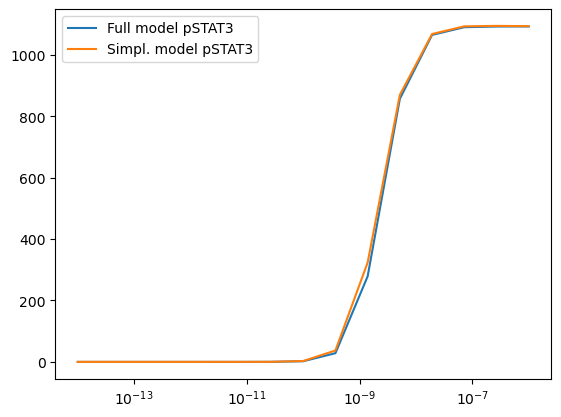

In [6]:
plt.plot(IL10vec,pSTAT3_full, label = "Full model pSTAT3")
plt.plot(IL10vec,pSTAT3_simpl, label = "Simpl. model pSTAT3")
plt.xscale("log")
plt.legend(loc="best")

As we can see the simplified model behaves very similar to the complete one, the slight differences coming from numerical errors in the simulation.

However the model is still to large to get the SS through linear franework. Since binding of RB without RA is uncommon, we decide to remove it from the model to further simplify it.

In [4]:
def model_func_simpl2(PA,IC):
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    # Initialize model
    Model()
    
    # Compartment
    Compartment(name='EC', parent=None, dimension=3, size=None)
    Compartment(name='Cell_PM', parent=EC, dimension=2, size=None)
    Compartment(name='Cell_CP', parent=Cell_PM, dimension=3, size=None)
    
    # Monomers
    Monomer('ILM')
    Monomer('IL', ['bA1', 'bA2', 'bB1', 'bB2'])
    Monomer('RA', ['bA','kA'], {'kA': ['P','U']})
    Monomer('RB', ['bB']) 
    
    # Parameters (We put whatever number)
    Parameter('K_ILM_f', PA["k_ILM_f"]/(Na*PA["vol_EC"])*2)
    Parameter('K_ILM_b', PA["k_ILM_b"])
    
    Parameter('K_IL_RA_f', 2*PA["k_IL_RA_f"]/(Na*PA["vol_EC"]))
    Parameter('K_IL_RA_b', PA["k_IL_RA_b"])
    
    Parameter('K_IL_RA2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA2_b', PA["k_IL_RA_b"])
    
    Parameter('K_IL_RA_RB_f', PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM))
    Parameter('K_IL_RA_RB_b', PA["k_IL_RA_RB_b"])
    
    Parameter('K_IL_RA2_2_f', PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)*(1/2))
    
    Parameter('K_IL_RA2_3_b', PA["k_IL_RA_b"]*(1/2))
    Parameter('K_IL_RA_RB_3_b', PA["k_IL_RA_RB_b"]*(1/2))
    
    Parameter('K_IL_RA2_4_b', PA["k_IL_RA_b"]*2)
    Parameter('K_IL_RA_RB_4_b', PA["k_IL_RA_RB_b"]*2)
    
    Parameter('K_DEPHOS_R', PA["k_DEPHOS_R"])
    
    # Complexes and reactions (dimerization of IL) Not added, since the edges regarding dimerization have to be added later (violates LF rules of elements being both in a node and an edge label)
    ILM_free = ILM()
    IL_free = IL(bA1=None, bA2=None, bB1=None, bB2=None)
    Rule('IL_binding', ILM_free + ILM_free | IL_free, *[K_ILM_f, K_ILM_b])
    
    # Complexes and reactions (binding of receptors)
    IL_RA1p_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1,kA='P')
    Rule('IL_RA1p_alone_binding', IL_free + RA(bA=None,kA='P')| IL_RA1p_alone, *[K_IL_RA_f, K_IL_RA_b])
    IL_RA1_alone = IL(bA1=1, bA2=None, bB1=None, bB2=None) % RA(bA=1,kA='U')
    Rule('IL_RA1_alone_binding', IL_free + RA(bA=None,kA='U')| IL_RA1_alone, *[K_IL_RA_f, K_IL_RA_b])

    # Binding of second receptors from IL-RA1p complex
    IL_RA1p_RA2p = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='P')
    Rule('IL_RA1p_noRA2p_binding_DB', IL_RA1p_alone + RA(bA=None,kA='P') | IL_RA1p_RA2p, *[K_IL_RA2_2_f, K_IL_RA2_b])
    IL_RA1p_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='U')
    Rule('IL_RA1p_noRA2_binding_DB', IL_RA1p_alone + RA(bA=None,kA='U') | IL_RA1p_RA2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1p_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1p_noRB1_binding_DB', IL_RA1p_alone + RB(bB=None) | IL_RA1p_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    
    # Binding of second receptors from IL-RA1 complex
    IL_RA1_RA2 = IL(bA1=1, bA2=2, bB1=None, bB2=None) % RA(bA=1,kA='U') % RA(bA=2,kA='U')
    Rule('IL_RA1_noRA2_binding_DB', IL_RA1_alone + RA(bA=None,kA='U') | IL_RA1_RA2, *[K_IL_RA2_2_f, K_IL_RA2_b])
    Rule('IL_noRA1p_RA2_binding_DB', IL_RA1_alone + RA(bA=None,kA='P') | IL_RA1p_RA2, *[K_IL_RA2_f, K_IL_RA2_b])
    IL_RA1p_RB1 = IL(bA1=1, bA2=None, bB1=2, bB2=None) % RA(bA=1,kA='P') % RB(bB=2)
    Rule('IL_RA1_noRB1_binding_DB', IL_RA1_alone + RB(bB=None) >> IL_RA1p_RB1, K_IL_RA_RB_f)
    
    
    # Binding of third receptors to from IL-RA1p-RA2p-RB1 complex
    IL_RA1p_RA2p_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=3)
    Rule('IL_RA1p_RA2p_noRB1_binding_TB', IL_RA1p_RA2p + RB(bB=None) | IL_RA1p_RA2p_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_3_b])
    Rule('IL_RA1p_RA2_noRB1_binding_TB', IL_RA1p_RA2 + RB(bB=None) >> IL_RA1p_RA2p_RB1, K_IL_RA_RB_f)
    Rule('IL_RA1p_noRA2p_RB1_binding_TB', IL_RA1p_RB1 + RA(bA=None,kA='P') | IL_RA1p_RA2p_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    
    # Binding of third receptors to from IL-RA1p-RA2-RB1 complex
    IL_RA1p_RA2_RB1 = IL(bA1=1, bA2=2, bB1=3, bB2=None) % RA(bA=1,kA='P') % RA(bA=2,kA='U') % RB(bB=3)
    Rule('IL_RA1p_RA2_noRB1_binding_TB2', IL_RA1p_RA2 + RB(bB=None) | IL_RA1p_RA2_RB1, *[K_IL_RA_RB_f, K_IL_RA_RB_b])
    Rule('IL_RA1_RA2_noRB1_binding_TB', IL_RA1_RA2 + RB(bB=None) >> IL_RA1p_RA2_RB1, K_IL_RA_RB_f)
    Rule('IL_RA1p_noRA2_RB1_binding_TB', IL_RA1p_RB1 + RA(bA=None,kA='U') | IL_RA1p_RA2_RB1, *[K_IL_RA2_f, K_IL_RA2_b])
    
    # Binding of fourth receptor
    IL_RA1p_RA2p_RB1_RB2 = IL(bA1=1, bA2=2, bB1=3, bB2=4) % RA(bA=1,kA='P') % RA(bA=2,kA='P') % RB(bB=3) % RB(bB=4)
    Rule('IL_RA1p_RA2p_RB1_noRB2_binding_QB', IL_RA1p_RA2p_RB1 + RB(bB=None) | IL_RA1p_RA2p_RB1_RB2, *[K_IL_RA_RB_f, K_IL_RA_RB_4_b])
    Rule('IL_RA1p_RA2_RB1_noRB2_binding_QB', IL_RA1p_RA2_RB1 + RB(bB=None) >> IL_RA1p_RA2p_RB1_RB2, K_IL_RA_RB_f)
    
    # Dephosphorylation of receptors
    Rule('RA_DEPHOS', RA(bA=None, kA='P') >> RA(bA=None, kA='U'), K_DEPHOS_R)
    Rule('IL_RA1p_DEPHOS', IL_RA1p_alone >> IL_RA1_alone, K_DEPHOS_R)
    Rule('IL_RA1p_RA2p_DEPHOS', IL_RA1p_RA2p >> IL_RA1p_RA2, K_DEPHOS_R)
    Rule('IL_RA1p_RA2_DEPHOS', IL_RA1p_RA2 >> IL_RA1_RA2, K_DEPHOS_R)
    Rule('IL_RA1p_RA2p_RB1_DEPHOS', IL_RA1p_RA2p_RB1 >> IL_RA1p_RA2_RB1, K_DEPHOS_R)
    
    # Initial conditions
    Kd_IL = PA["k_ILM_b"]/(PA["k_ILM_f"]/(Na*PA["vol_EC"]))
    ILM_eq = (-Kd_IL/2 + (Kd_IL**2/4 + 2*Kd_IL*IC["IL0"]*Na*PA["vol_EC"])**(1/2))/2
    ILD_eq = (IC["IL0"]*Na*PA["vol_EC"]-ILM_eq)/2
    Parameter('ILM_0', ILM_eq)
    Initial(ILM() ** EC , ILM_0)
    Parameter('ILD_0', ILD_eq)
    Initial(IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC, ILD_0)
    
    Parameter('RA_0',IC["RA0"])
    Parameter('RB_0',IC["RB0"])
    Initial(RA(bA=None, kA='U') ** Cell_PM, RA_0)
    Initial(RB(bB=None) ** Cell_PM, RB_0)
    
    # Simulation
    Observable('ILM_free', ILM() ** EC)
    Observable('IL_free', IL(bA1=None, bA2=None, bB1=None, bB2=None) ** EC)
    Observable('RA_free', RA(bA=None,kA='U') ** Cell_PM)
    Observable('RAp_free', RA(bA=None,kA='P') ** Cell_PM)
    Observable('RB_free', RB(bB=None) ** Cell_PM)
    
    Observable('IL_RA1', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1,kA='U') ** Cell_PM)
    Observable('IL_RA1p', IL(bA1=1, bA2=None, bB1=None, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM)
    
    Observable('IL_RA1p_RA2p', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='P') ** Cell_PM)
    Observable('IL_RA1p_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='U') ** Cell_PM)
    Observable('IL_RA1_RA2', IL(bA1=1, bA2=2, bB1=None, bB2=None) ** EC % RA(bA=1,kA='U') ** Cell_PM % RA(bA=2,kA='U') ** Cell_PM)
    Observable('IL_RA1p_RB1', IL(bA1=1, bA2=None, bB1=2, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RB(bB=2) ** Cell_PM)
    
    Observable('IL_RA1p_RA2p_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM)
    Observable('IL_RA1p_RA2_RB1', IL(bA1=1, bA2=2, bB1=3, bB2=None) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='U') ** Cell_PM % RB(bB=3) ** Cell_PM)
    
    Observable('IL_RA1p_RA2p_RB1_RB2', IL(bA1=1, bA2=2, bB1=3, bB2=4) ** EC % RA(bA=1,kA='P') ** Cell_PM % RA(bA=2,kA='P') ** Cell_PM % RB(bB=3) ** Cell_PM % RB(bB=4) ** Cell_PM)
    Observable('RAp', RA(kA='P') ** Cell_PM)
    
    dT, Tf = func_time(IC["IL0"])
    t = np.arange(0,Tf*5,dT/50)
    simulator = ScipyOdeSimulator(model, tspan=t, compiler='python', integrator = 'lsoda').run()
    
    return simulator.all

In [61]:
start_time = time()
pSTAT1_simpl = []
pSTAT3_simpl = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_simpl2(PA,IC)
    # pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_simpl.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 21.193154 seconds


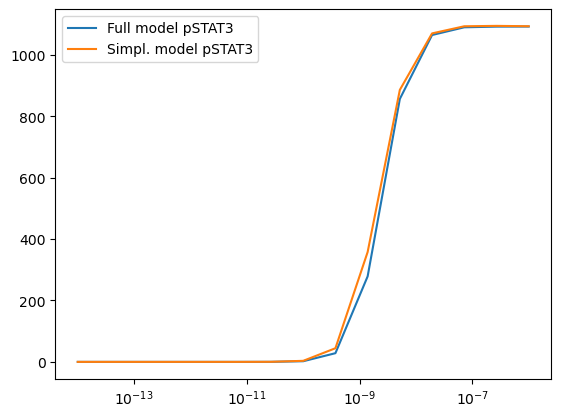

In [62]:
plt.plot(IL10vec,pSTAT3_full, label = "Full model pSTAT3")
plt.plot(IL10vec,pSTAT3_simpl, label = "Simpl. model pSTAT3")
plt.xscale("log")
plt.legend(loc="best")

At binding rates around 10/100 times higher than WT measured values the simplified model still behaves very similar to the non-simplified one -> We use it to find the SS

Using the simplified model, we got the SS solution using linear framework. Now we use the SS solution to check if it still behaves like the non-simplified model.

In [5]:
def simulate_model(PA,IC):
    def IL10_model_RA_RB(x):
        RA = x[0]
        RAp = x[1]
        RB = x[2]
        IL10M = x[3]
        
        RA_expr = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) - RA + RA0 - RAp
        RAp_expr = (-16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 32.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 8.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 - 32.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 8.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp - 8.0*IL10M*IL10M0*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp - 64.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 112.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 40.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 96.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 56.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 144.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 160.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 40.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 - 96.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 112.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 36.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 40.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 32.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 28.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 28.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 40.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB - 64.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 152.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 80.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 36.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 12.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 104.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 72.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp - 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 64.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 28.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 24.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 - 96.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 120.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 52.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 - 48.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 64.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 4.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp + 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp + 16.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 40.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp - 80.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 128.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 104.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 152.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 200.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 80.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 44.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 - 96.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 144.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 52.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 88.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp - 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 72.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 52.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 68.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 68.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 92.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 36.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 40.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB - 116.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 320.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 164.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 40.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 44.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 10.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 40.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 - 40.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 240.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 160.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 96.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 40.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 92.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 132.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 34.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 136.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 - 152.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 288.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB - 116.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 124.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 28.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 112.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 - 80.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 192.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 - 80.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 96.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp + 72.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 56.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 36.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp + 128.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 - 56.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp - 20.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 + 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 74.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 78.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 56.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 76.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 - 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 + 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB - 34.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 90.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 44.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 18.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 6.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 + 56.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 180.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 128.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 62.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 26.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 120.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 104.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 88.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp - 6.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 + 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 72.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 20.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB - 42.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 42.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 104.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 - 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 136.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 72.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 80.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 28.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB + 28.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB + 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 - 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 80.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 16.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 - 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 48.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 4.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b**2*K_IL_RA_f*RAp + 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB + 64.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 - 8.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 32.0*IL10M*IL10M0*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 72.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 20.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 52.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 20.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 56.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 144.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 84.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 6.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 104.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 64.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 56.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 68.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 6.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 192.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 144.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 104.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 20.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 144.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 - 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp + 104.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 52.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp + 240.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 120.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp - 20.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 + 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 38.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 58.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 20.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 44.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp - 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 + 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 10.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 70.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 10.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 2.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 + 160.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 208.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 84.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 132.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 52.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 6.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 136.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 184.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 64.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 112.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 64.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 104.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB - 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp - 2.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 + 128.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 60.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 68.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 60.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 42.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 288.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 152.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 136.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 248.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 212.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 68.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB + 56.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB + 192.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 - 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b**2*K_IL_RA_f*RAp + 184.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 36.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 92.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB + 240.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 56.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 120.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**2 + 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 64.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 34.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 22.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 68.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 66.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 2.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 14.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 2.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 112.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 204.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 64.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 26.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 6.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 88.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 144.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 6.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 2.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 56.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 68.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 78.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 6.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB + 144.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 96.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 144.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 160.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 12.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB**2 + 28.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB**2 + 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 48.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 - 32.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 16.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 4.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB + 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**2 + 80.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RB**4 + 24.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp*RB**4 + 40.0*IL10M*IL10M0*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**3 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp + 128.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 28.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 28.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 20.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 52.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 + 104.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 224.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 120.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 52.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 160.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 104.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RA*RAp + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*K_IL_RA_f*RAp**2 + 176.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 176.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 176.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 296.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b**2*K_IL_RA_f*RAp + 128.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB + 192.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**2 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 20.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 88.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 128.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 30.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 30.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 144.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 328.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 184.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 140.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 92.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 20.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 112.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 224.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 112.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 128.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 22.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 88.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 184.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 56.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB + 176.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 176.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 208.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 336.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB**2 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB**2 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*K_IL_RA_f*RAp*RB + 112.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 56.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 56.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**2 + 128.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RB**4 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp*RB**4 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**3 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 20.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 60.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 68.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RB**4 + 56.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 + 56.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 12.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 28.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 76.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 26.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 22.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 152.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 88.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 84.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 52.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RB**5 + 96.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RB**4 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 18.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 40.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 48.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 92.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 20.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB**2 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB**2 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 64.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 80.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 128.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 24.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*K_IL_RA_f*RA*RAp*RB**3 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*K_IL_RA_f*RAp**2*RB**3 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RB**6 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp*RB**6 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RB**5 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**5 + 8.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 4.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**2 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RB**4 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp*RB**4 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**3 + 32.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RB**5 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp*RB**5 + 16.0*IL10M*IL10M0*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b**2*K_IL_RA_f*RAp*RB**4 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 24.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 56.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 24.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 56.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 40.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 40.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 4.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 24.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 - 24.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 56.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 32.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 20.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 44.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 24.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 16.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 8.0*IL10M*K_DEPHOS_R**5*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 112.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 224.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 112.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 112.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 248.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 136.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 36.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 72.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 72.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 - 72.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 216.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 216.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 - 144.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 144.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 12.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 176.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 176.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 196.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 220.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 80.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 84.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 96.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 36.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 12.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 60.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 132.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 72.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 44.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 236.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 516.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 280.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 - 220.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 492.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 272.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 72.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 144.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 72.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*RAp - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 88.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 88.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 160.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 160.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 80.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 80.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4*RAp - 36.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp**2 - 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**3 - 36.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**4 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**5 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 36.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 36.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 18.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 28.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 18.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 12.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp - 44.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 - 48.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 - 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 196.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 220.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 80.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**4 - 62.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 222.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 256.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 96.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 28.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 100.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 116.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 44.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 20.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp - 12.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 - 48.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 112.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 - 114.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 254.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 140.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 64.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 108.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 228.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 120.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 20.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 48.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 80.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 168.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 304.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 136.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 168.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 360.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 192.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 52.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 104.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 104.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 - 152.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 408.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 408.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 - 304.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 304.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 14.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 316.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 280.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 76.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 384.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 408.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 136.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 156.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 30.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 132.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 256.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 124.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 - 140.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 132.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 588.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 1200.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 612.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 28.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 216.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 - 560.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 1216.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 656.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 256.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 152.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 304.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 152.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*RAp - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 280.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 280.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 - 184.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 624.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 624.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 200.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 200.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 368.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 368.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4*RAp - 100.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp**2 - 138.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**3 - 74.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**4 - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**5 - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 120.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 192.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 120.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 60.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 60.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2*RAp - 6.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp**2 - 2.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**3 - 48.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp - 154.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 - 146.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 42.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 18.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 244.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 782.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 782.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 244.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 124.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 104.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**4 - 278.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 938.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 1012.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 352.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 160.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 160.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 368.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 400.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA*RAp - 2.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp**2 - 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 - 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 - 38.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 34.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 232.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 468.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 236.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA*RAp - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp**2 - 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 88.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 638.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 1358.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 720.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 28.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 28.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 180.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 464.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 172.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 604.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 1288.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 684.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 180.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 460.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 184.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 184.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 368.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 184.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b**2*RAp - 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp - 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 168.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 168.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 288.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 288.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 128.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4*RAp - 18.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp**2 - 28.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**3 - 18.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**4 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**5 - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 108.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 168.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 108.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 34.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 153.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 238.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 153.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 34.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RAp*RB**3 - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp**2*RB**3 - 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**3*RB**3 - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**4*RB**3 - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**5*RB**3 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3*RAp - 14.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp**2 - 14.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**4 - 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 136.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 140.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**4 - 134.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 447.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 475.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 162.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 120.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 120.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 164.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 546.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 592.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 210.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 34.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 170.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 170.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 34.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 68.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 - 224.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 - 244.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 - 88.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**3 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**3 - 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**3 - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**3 - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**3 - 92.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 188.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 218.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 448.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 230.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 82.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 232.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 82.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 212.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 428.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 216.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 84.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 200.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 84.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 - 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 - 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 - 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 - 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 256.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 256.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 - 208.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 208.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 88.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 236.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 52.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 88.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 308.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 316.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 196.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 92.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 - 148.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 132.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 512.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 1012.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 500.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 232.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 88.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 - 488.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 1024.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 536.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 320.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 208.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*RAp - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 - 116.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 248.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 248.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 52.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 - 216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 664.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 664.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 344.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 344.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 432.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 432.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 240.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 240.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4*RAp - 92.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp**2 - 118.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**3 - 62.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**4 - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**5 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 132.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 132.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 66.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 108.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 66.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2*RAp - 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp**2 - 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**3 - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp - 170.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 - 154.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 78.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 304.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 950.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 922.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 276.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 124.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**4 - 352.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 1176.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 1220.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 396.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 132.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 412.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 428.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 148.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA*RAp - 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp**2 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp - 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 - 82.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 84.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 308.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 624.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 316.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA*RAp - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp**2 - 76.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 176.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 - 164.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 180.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 936.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 1944.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 1008.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 68.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 340.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 816.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 316.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 868.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 1808.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 940.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 352.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 916.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 364.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 432.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 240.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b**2*RAp - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 - 148.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 344.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 344.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 92.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 208.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 208.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 664.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 664.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 424.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 424.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 - 240.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 240.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4*RAp - 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp**2 - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**3 - 26.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**4 - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**5 - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 220.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 332.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 68.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 337.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 540.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 341.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 70.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RAp*RB**3 - 156.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp**2*RB**3 - 248.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**3*RB**3 - 156.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**4*RB**3 - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**5*RB**3 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3*RAp - 26.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp**2 - 22.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**4 - 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 332.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 328.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 92.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**4 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 - 42.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 - 22.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 - 360.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 1203.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 1237.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 394.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 280.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 260.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 60.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 442.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 1440.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 1500.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 502.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 86.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 438.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 442.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 90.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 - 524.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 - 544.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 - 188.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**3 - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**3 - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**3 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**3 - 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**3 - 38.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 46.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 288.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 588.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 300.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 108.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 304.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 - 76.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 - 716.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 1466.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 750.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RAp*RB**2 - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp**2*RB**2 - 322.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 872.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 326.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 656.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 1332.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 676.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 344.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 860.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 356.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 - 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 - 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 - 240.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 - 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 136.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 136.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 - 224.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 224.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 - 160.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 160.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 - 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 - 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 18.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 18.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 126.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 196.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 126.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 46.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RAp*RB**3 - 207.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp**2*RB**3 - 322.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**3*RB**3 - 207.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**4*RB**3 - 46.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**5*RB**3 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RAp*RB**4 - 90.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp**2*RB**4 - 140.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**3*RB**4 - 90.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**4*RB**4 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**5*RB**4 - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 150.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 154.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 146.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 477.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 493.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 162.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 140.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 140.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 178.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 - 564.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 - 584.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 - 198.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 - 46.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**3 - 230.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**3 - 230.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**3 - 46.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**3 - 68.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RAp*RB**5 - 212.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp**2*RB**5 - 220.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**3*RB**5 - 76.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**4*RB**5 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**4 - 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**4 - 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**4 - 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**4 - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 88.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 164.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 76.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 374.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 174.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 102.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 296.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 102.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 180.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 - 348.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 - 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 - 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 - 264.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 - 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RAp*RB**6 - 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp**2*RB**6 - 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**3*RB**6 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**5 - 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**5 - 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**5 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 272.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 256.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4*RAp - 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp**2 - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**3 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**4 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**5 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2*RAp - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**3 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp - 60.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 - 60.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 116.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 364.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 360.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**4 - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 460.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 464.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 140.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA*RAp - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA*RAp - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 - 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 376.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 776.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 400.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 184.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 416.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 688.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 504.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b**2*RAp - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 320.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 320.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 320.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 320.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4*RAp - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**4 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**5 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 34.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 184.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 302.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 188.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RAp*RB**3 - 84.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp**2*RB**3 - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**3*RB**3 - 84.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**4*RB**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**5*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3*RAp - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp**2 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**4 - 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 196.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 216.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**4 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 - 214.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 742.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 780.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 252.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 160.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 160.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 268.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 872.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 884.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 280.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 268.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 272.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 - 288.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 - 288.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**3 - 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**3 - 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**3 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**3 - 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB - 44.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**3 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 180.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 388.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 232.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 - 476.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 980.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 504.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp**2*RB**2 - 276.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 728.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 304.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 424.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 840.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 416.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 288.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 736.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 304.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RAp*RB - 26.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp**2*RB - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**3*RB - 34.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**4*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**5*RB - 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 148.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 248.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 164.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 46.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RAp*RB**3 - 226.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp**2*RB**3 - 362.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**3*RB**3 - 230.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**4*RB**3 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**5*RB**3 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RAp*RB**4 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp**2*RB**4 - 152.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**3*RB**4 - 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**4*RB**4 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**5*RB**4 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB - 22.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB - 26.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB - 2.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 - 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 224.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 248.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB - 44.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**4*RB - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 - 190.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 656.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 690.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 224.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 224.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 - 708.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 - 716.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 - 232.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**3 - 288.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**3 - 292.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**3 - 60.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**3 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RAp*RB**5 - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp**2*RB**5 - 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**3*RB**5 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**4*RB**5 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**4 - 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**4 - 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**4 - 2.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 - 132.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 260.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RAp*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp**2*RB**2 - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 232.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4 - 292.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 568.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 276.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RA*RAp*RB**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp**2*RB**3 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 536.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 212.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 248.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 - 480.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 - 232.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 - 192.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 - 472.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 - 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RAp*RB**6 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp**2*RB**6 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**3*RB**6 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**5 - 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**5 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**5 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_b*RAp*RB**5 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b**2*RAp*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp*RB**6 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**2*RB**6 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**5 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**5 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RAp*RB**2 - 18.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp**2*RB**2 - 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**3*RB**2 - 18.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**4*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**5*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RAp*RB**3 - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp**2*RB**3 - 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**3*RB**3 - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**4*RB**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**5*RB**3 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RAp*RB**4 - 90.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp**2*RB**4 - 140.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**3*RB**4 - 90.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**4*RB**4 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**5*RB**4 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA**4*RAp*RB**5 - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RAp**2*RB**5 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp**3*RB**5 - 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**4*RB**5 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**5*RB**5 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 - 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 - 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 - 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 - 92.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 - 92.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 - 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**2 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**2 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**2 - 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 - 214.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 - 214.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 - 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**3 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**3 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**3 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**3 - 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RAp*RB**5 - 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp**2*RB**5 - 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**3*RB**5 - 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**4*RB**5 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**4 - 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**4 - 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**4 - 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RA**3*RAp*RB**6 - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RAp**2*RB**6 - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp**3*RB**6 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**4*RB**6 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**3*RAp*RB**5 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RAp**2*RB**5 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp**3*RB**5 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**4*RB**5 - 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 - 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 - 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 - 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 - 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 - 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 - 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 - 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 - 124.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 - 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 - 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 - 144.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 - 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 - 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RAp*RB**6 - 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp**2*RB**6 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**3*RB**6 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**5 - 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**5 - 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**5 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**7*K_IL_RA_f*RA**2*RAp*RB**7 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**7*K_IL_RA_f*RA*RAp**2*RB**7 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**7*K_IL_RA_f*RAp**3*RB**7 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**6 - 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**6 - 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**6 - 8.0*K_DEPHOS_R**5*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 8.0*K_DEPHOS_R**5*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 8.0*K_DEPHOS_R**5*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 8.0*K_DEPHOS_R**5*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 8.0*K_DEPHOS_R**5*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 32.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 40.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 32.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 36.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 72.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 12.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 4.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 12.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 40.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 44.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 4.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*RAp - 40.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 40.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 40.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 64.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 44.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 52.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 152.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 32.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 24.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 36.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 14.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 40.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 30.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 140.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 132.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 32.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 28.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 12.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*RAp - 128.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 36.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 184.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 64.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2*RAp - 6.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp**2 - 2.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**3 - 24.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 42.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 18.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA*RAp - 2.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp**2 - 38.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 34.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA*RAp - 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp**2 - 72.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 88.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 28.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 28.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 12.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b**2*RAp - 72.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 32.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 72.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 32.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 16.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*RAp - 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 24.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*RAp - 104.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 24.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 36.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 14.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 34.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 148.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 132.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 8.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*RAp - 116.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 52.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 216.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 120.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 8.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2*RAp - 14.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp**2 - 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**3 - 48.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 78.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 36.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 8.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA*RAp - 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp**2 - 82.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 84.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA*RAp - 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp**2 - 164.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 180.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 68.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 56.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 24.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b**2*RAp - 148.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 92.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 184.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 120.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 20.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 - 42.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 - 22.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 - 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 38.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 46.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 8.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 8.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 56.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 - 76.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 - 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RAp*RB**2 - 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp**2*RB**2 - 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 8.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 56.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 56.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 - 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2*RAp - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp**2 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**3 - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 - 48.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 48.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA*RAp - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp**2 - 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2*RAp - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp**2 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**3 - 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 36.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA*RAp - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp**2 - 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 48.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA*RAp - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp**2 - 88.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 96.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b**2*RAp - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 96.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 96.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB - 14.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB - 20.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 - 36.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 - 20.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 - 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB - 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RAp*RB - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp**2*RB - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 - 80.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 - 32.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RAp*RB**2 - 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp**2*RB**2 - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB - 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 - 64.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 - 2.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 - 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 - 2.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 - 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 - 20.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RAp*RB**2 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp**2*RB**2 - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 - 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4 - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RA*RAp*RB**3 - 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp**2*RB**3 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 - 4.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_b*RAp*RB**5 - 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b**2*RAp*RB**4)/(8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 + 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*RA + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_f*RAp + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp + 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 40.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 4.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 20.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 56.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 32.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 20.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 44.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 24.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 16.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 8.0*IL10M*K_DEPHOS_R**4*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 224.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp + 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 + 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 248.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 136.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b + 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA + 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp + 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 216.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 216.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp + 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 176.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp + 176.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 + 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 + 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 196.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 220.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 84.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 60.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 132.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp + 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 236.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 516.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 280.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2 + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 220.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 492.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 272.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 144.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 72.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*RA + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_f*RAp + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 88.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 88.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 160.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 160.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp + 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 + 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 36.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 18.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 28.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 18.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp + 48.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 56.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 196.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 220.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3 + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 62.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 222.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 256.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 96.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 28.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 100.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 116.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 44.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 4.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 12.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 48.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 112.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2 + 32.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 114.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 254.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 140.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 64.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 24.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 108.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 228.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 120.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 48.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 20.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 80.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 40.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 16.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 8.0*IL10M*K_DEPHOS_R**3*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_f*RA + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_f*RAp + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 304.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp + 136.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 + 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 360.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 192.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 52.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b + 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA + 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp + 152.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 408.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 408.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp + 304.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 304.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 316.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp + 280.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 + 76.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 + 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 384.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 408.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 136.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 144.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 156.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 56.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 30.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 132.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 256.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp + 124.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 140.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 132.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 588.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 1200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 612.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2 + 216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 560.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 1216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 656.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 256.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 152.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 304.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 152.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 280.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 280.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 624.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 624.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 100.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp + 138.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 + 74.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 192.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 60.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 60.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 6.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp + 2.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 + 48.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 154.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp + 146.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 42.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 18.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 244.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 782.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 782.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 244.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3 + 124.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 104.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 278.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 938.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 1012.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 352.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 160.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 160.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 400.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 144.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA + 2.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp + 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp + 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 38.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 232.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 468.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 236.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp + 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2 + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp + 36.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 88.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 638.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 1358.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 720.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 180.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 464.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 172.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 604.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 1288.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 684.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 180.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 460.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 368.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 184.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b**2 + 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA + 8.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 288.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 288.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 128.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 144.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RB**4 + 144.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp*RB**4 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 18.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp + 28.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 + 18.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 108.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 168.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 108.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 153.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 238.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 153.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp + 14.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 + 40.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 136.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 140.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 44.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**3 + 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 20.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 + 134.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 447.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 475.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 162.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 120.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 164.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 546.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 592.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 210.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 170.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 170.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 34.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 68.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 224.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 244.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 88.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 80.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 24.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 12.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA**2 + 16.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp + 4.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 + 92.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 188.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 96.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 112.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 218.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 448.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 230.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 82.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 232.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 82.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 212.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 428.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 216.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 84.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 200.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 84.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 144.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 72.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 64.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 32.0*IL10M*K_DEPHOS_R**2*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_f*RA + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_f*RAp + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 168.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp + 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_f*RA + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_f*RAp + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 256.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 256.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp + 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 236.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 + 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 + 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 308.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 316.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 34.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 196.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp + 92.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 148.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 132.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 512.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 1012.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 500.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2 + 232.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp + 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 488.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 1024.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 536.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 320.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_f*RA + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_f*RAp + 116.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 248.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 248.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 52.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA + 104.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 216.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 664.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 664.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 432.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 432.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 92.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp + 118.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 + 62.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 132.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 216.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 132.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 66.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 108.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 66.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp + 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 170.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp + 154.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 78.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 304.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 950.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 922.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 276.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3 + 124.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 352.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 1176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 1220.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 396.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 132.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 412.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 428.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 148.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA + 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 44.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 82.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 84.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 308.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 624.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 316.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp + 76.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2 + 176.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp + 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 164.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 180.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 936.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 1944.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 1008.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 340.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 816.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 316.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 868.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 1808.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 940.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 352.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 916.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 364.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 216.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 432.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 216.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RB + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp + 148.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 92.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 208.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 184.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 664.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 664.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 424.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 424.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 368.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RB**4 + 368.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp*RB**4 + 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 34.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 + 26.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 220.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 332.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 337.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 540.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 341.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 70.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 156.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 248.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 156.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 26.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp + 22.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 + 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 332.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 328.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 92.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**3 + 44.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 42.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 22.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 360.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 1203.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 1237.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 394.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 64.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 280.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 260.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 60.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 442.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 1440.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 1500.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 502.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 86.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 438.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 442.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 90.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 168.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 524.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 544.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 188.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 72.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA**2 + 32.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 + 38.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 46.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 288.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 588.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 300.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 108.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 304.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 76.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 716.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 1466.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 750.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RB**2 + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 + 322.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 872.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 326.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 656.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 1332.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 676.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 344.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 860.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 356.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 184.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 368.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 184.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 240.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 120.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 136.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 96.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4 + 224.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RB**4 + 224.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp*RB**4 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RB**3 + 160.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 160.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RB**5 + 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp*RB**5 + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RB**4 + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp*RB**4 + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 18.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 18.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 126.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 196.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 126.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 46.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 207.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 322.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 207.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 46.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RB**4 + 90.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 + 140.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 + 90.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 14.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 44.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 150.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 154.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 48.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 146.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 477.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 493.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 162.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 140.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 140.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 28.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 178.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 564.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 584.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 198.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 46.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 230.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 230.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 46.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 68.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RB**5 + 212.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 + 220.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 + 76.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RB**4 + 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 + 100.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 + 20.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 24.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 12.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 16.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 4.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 88.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 164.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 76.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 128.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 36.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 200.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 374.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 174.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 102.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 296.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 102.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 180.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 348.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 168.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 264.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RB**6 + 112.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp*RB**6 + 56.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**2*RB**6 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RB**5 + 80.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**5 + 40.0*IL10M*K_DEPHOS_R*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**5 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**5*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp + 56.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**3 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 88.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 88.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**2 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 272.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2 + 80.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**2 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 256.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 176.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 176.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 176.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 176.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**4*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**4 + 28.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**3*RAp + 36.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA**2*RAp**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RA*RAp**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_f*RAp**4 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 80.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3 + 60.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp + 60.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**3 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 36.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 116.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 364.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 360.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 112.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**3 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*K_IL_RA_f*RAp**3 + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 460.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 464.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 140.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 80.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 80.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 144.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 144.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 112.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 240.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2 + 80.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**2 + 88.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 376.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 776.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 400.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 184.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 416.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 176.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 344.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 688.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 344.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 504.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 200.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RB + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 144.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 144.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 144.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 144.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 320.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 320.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 320.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 320.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RB**4 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp*RB**4 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**4 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**3*RAp + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA**2*RAp**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RA*RAp**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_f*RAp**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 112.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 176.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 112.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 34.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 184.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 302.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 188.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 36.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 84.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 84.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**3 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA**2*RAp + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RA*RAp**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_f*RAp**3 + 6.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 196.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 216.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 72.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**3 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*K_IL_RA_f*RAp**3 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 36.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 214.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 742.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 780.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 252.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 160.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 160.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 268.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 872.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 884.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 280.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 52.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 268.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 272.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 56.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 288.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 288.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 120.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 120.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 6.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RB + 44.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**2*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RA*RAp + 8.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*K_IL_RA_f*RAp**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 180.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 388.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 208.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 88.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 232.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 104.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 80.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 476.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 980.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 504.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 + 276.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 728.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 304.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 424.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 840.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 416.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 288.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 736.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 304.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RB**2 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp*RB**2 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RB + 24.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp*RB + 56.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 56.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 136.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4 + 240.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RB**4 + 240.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RB**3 + 240.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 240.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RB**5 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp*RB**5 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RB**4 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp*RB**4 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**4*RB + 26.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RAp*RB + 48.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp**2*RB + 34.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**3*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_f*RAp**4*RB + 28.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 148.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 248.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 164.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 36.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 46.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 226.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 362.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 230.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RB**4 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 + 152.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 + 96.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**3*RB + 22.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA**2*RAp*RB + 26.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RA*RAp**2*RB + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_f*RAp**3*RB + 2.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 6.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 224.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 248.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 80.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**3*RB + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB + 44.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB + 12.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**3*RB + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 12.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 190.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 656.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 690.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 224.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 200.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 208.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 48.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 224.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 708.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 716.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 232.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 56.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 288.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 292.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 60.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 80.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RB**5 + 240.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 + 240.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 + 80.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RB**4 + 120.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 + 120.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 + 2.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp*RB**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**2*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA**2*RB + 32.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB + 12.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*K_IL_RA_f*RAp**2*RB + 12.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 20.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 132.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 260.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 + 72.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 232.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 88.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 + 292.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 568.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 276.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RA*RB**3 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 536.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 212.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 248.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 480.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 232.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 192.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 472.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 200.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RB**6 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp*RB**6 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**2*RB**6 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RB**5 + 128.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**5 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**5 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RB**3 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RAp*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RB**2 + 8.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RB**4 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp*RB**4 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b**2*RB**3 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RB**3 + 40.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp*RB**3 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_b*RB**5 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RB**5 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp*RB**5 + 16.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b**2*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp*RB**4 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RB**6 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RAp*RB**6 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RB**5 + 32.0*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp*RB**5 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**4*RB**2 + 18.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RAp*RB**2 + 28.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp**2*RB**2 + 18.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**3*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**4*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**4*RB**3 + 72.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RAp*RB**3 + 112.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp**2*RB**3 + 72.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**3*RB**3 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**4*RB**3 + 20.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**4*RB**4 + 90.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RAp*RB**4 + 140.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp**2*RB**4 + 90.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**3*RB**4 + 20.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**4*RB**4 + 8.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA**4*RB**5 + 36.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RAp*RB**5 + 56.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp**2*RB**5 + 36.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**3*RB**5 + 8.0*IL10M*K_ILM_f*K_IL_RA2_f**3*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**4*RB**5 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**3*RB**2 + 14.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA**2*RAp*RB**2 + 14.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RA*RAp**2*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_f*RAp**3*RB**2 + 28.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**3*RB**3 + 92.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RAp*RB**3 + 92.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp**2*RB**3 + 28.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**3*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**3*RB**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**2 + 20.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**2 + 68.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**3*RB**4 + 214.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RAp*RB**4 + 214.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp**2*RB**4 + 68.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**3*RB**4 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**3*RB**3 + 80.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**3 + 80.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**3 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**3 + 68.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**3*RB**5 + 208.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RAp*RB**5 + 208.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp**2*RB**5 + 68.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**3*RB**5 + 20.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**3*RB**4 + 100.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**4 + 100.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**4 + 20.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RA**3*RB**6 + 72.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RAp*RB**6 + 72.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp**2*RB**6 + 24.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**3*RB**6 + 8.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**3*RB**5 + 40.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RAp*RB**5 + 40.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp**2*RB**5 + 8.0*IL10M*K_ILM_f*K_IL_RA2_f**2*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**3*RB**5 + 8.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA**2*RB**3 + 12.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RA*RAp*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_f*RAp**2*RB**3 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA**2*RB**2 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**2 + 4.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**2 + 40.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA**2*RB**4 + 64.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RA*RAp*RB**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_f*RAp**2*RB**4 + 24.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA**2*RB**3 + 80.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**3 + 24.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**3 + 72.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA**2*RB**5 + 124.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RA*RAp*RB**5 + 52.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_f*RAp**2*RB**5 + 52.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA**2*RB**4 + 144.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**4 + 52.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**4 + 56.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA**2*RB**6 + 104.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RA*RAp*RB**6 + 48.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**6*K_IL_RA_f*RAp**2*RB**6 + 48.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA**2*RB**5 + 112.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**5 + 48.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**5*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**5 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**7*K_IL_RA_f*RA**2*RB**7 + 32.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**7*K_IL_RA_f*RA*RAp*RB**7 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**7*K_IL_RA_f*RAp**2*RB**7 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_b*K_IL_RA_f*RA**2*RB**6 + 32.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_b*K_IL_RA_f*RA*RAp*RB**6 + 16.0*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**6*K_IL_RA_b*K_IL_RA_f*RAp**2*RB**6 + 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b + 8.0*K_DEPHOS_R**4*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 32.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b + 40.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 36.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b + 72.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 12.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 12.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 40.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 44.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 4.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b + 40.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 40.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8.0*K_DEPHOS_R**3*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b + 64.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 44.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 52.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b + 152.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 32.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 24.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 36.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 14.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 30.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 140.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 132.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b + 128.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 36.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 184.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 64.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 4.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 6.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp + 2.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 + 24.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 42.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 18.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA + 2.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp + 38.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 34.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA + 4.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp + 72.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 88.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 28.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 12.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RB + 4.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_b**2 + 72.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 72.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 32.0*K_DEPHOS_R**2*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 16.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b + 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b + 104.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 36.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 14.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 34.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 148.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 132.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 28.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b + 116.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 52.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 216.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 120.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 14.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp + 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 + 48.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 78.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA + 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp + 82.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 84.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA + 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp + 164.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 180.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 68.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 24.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RB + 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_b**2 + 148.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 92.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 184.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 120.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 42.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 22.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 38.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 46.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 76.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 28.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RB**2 + 28.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 + 12.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 56.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4 + 40.0*K_DEPHOS_R*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RB**3 + 8.0*K_ILM_b*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8.0*K_ILM_b*K_IL_RA2_b**5*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16.0*K_ILM_b*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 16.0*K_ILM_b*K_IL_RA2_b**5*K_IL_RA_RB_b**2*K_IL_RA_b**2 + 8.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 12.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 12.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RA + 12.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b*RAp + 48.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RA + 8.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_b**2*RAp + 24.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 24.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**3*K_IL_RA_b**2 + 64.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 64.0*K_ILM_b*K_IL_RA2_b**4*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 4.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA**2 + 8.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RA*RAp + 4.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_b*RAp**2 + 24.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 36.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RA + 4.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_b*RAp + 40.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 8.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RA + 8.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_b**2*RAp + 88.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 40.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 24.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 8.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RB + 8.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**4*K_IL_RA_b**2 + 64.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 64.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 96.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 96.0*K_ILM_b*K_IL_RA2_b**3*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 6.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 36.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 12.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RA*RB + 12.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f*K_IL_RA_b**2*RAp*RB + 64.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 80.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 32.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RB**2 + 24.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 + 12.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 12.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**4*K_IL_RA_RB_f*K_IL_RA_b**2*RB + 56.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 56.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 64.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4 + 64.0*K_ILM_b*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RB**3 + 2.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 6.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 12.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 12.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 20.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RA*RB**2 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**3*K_IL_RA_RB_f**2*K_IL_RA_b**2*RAp*RB**2 + 16.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 24.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4 + 8.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RA*RB**3 + 8.0*K_ILM_b*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*K_IL_RA_b**2*RAp*RB**3 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4.0*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**4*K_IL_RA_RB_f**2*K_IL_RA_b**2*RB**2 + 16.0*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4 + 16.0*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**3*K_IL_RA_RB_f**3*K_IL_RA_b**2*RB**3 + 16.0*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**5*K_IL_RA_b*RB**5 + 16.0*K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**4*K_IL_RA_b**2*RB**4)
        RB_expr = -IL10M0*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) - RB + RB0
        IL_expr = -IL10M - IL10M0*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2)/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) + IL10M0
        return [RA_expr,RAp_expr,RB_expr,IL_expr]
    
    def SS_IL10_model_RA_RB():
        ILRA1pRB1 = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) - RB + RB0
        ILRA1p = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) - RA + RA0 - RAp
        ILRA1pRA2RB1 = -IL10M0*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) - RB + RB0
        ILRA1pRA2 = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(2*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4))) - RA/2 + RA0/2 - RAp/2
        ILRA1pRA2pRB1RB2 = -IL10M0*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3))/(2*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4))) - RB/2 + RB0/2
        ILRA1pRA2p = -IL10M0*(2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 4*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(2*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4))) - RA/2 + RA0/2 - RAp/2
        ILRA1pRA2pRB1 = -IL10M0*(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4))/(IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 62*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 25*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 30*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 5*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 10*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA_RB_f**5*RA*RB**5 + 8*K_IL_RA_RB_f**5*RAp*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + 2*IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA + 4*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 18*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 17*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 3*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 31*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 11*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 58*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 25*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 5*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 11*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 27*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 56*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 78*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 22*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 5*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 8*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4) + IL10M*K_ILM_f*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RA + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3 + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp + 14*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**3 + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**3 + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 34*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 256*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 56*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 156*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 64*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2 + 68*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3 + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**3 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 38*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 280*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 124*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 172*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 356*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 148*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 70*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 80*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**2 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RB + 96*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**3 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 92*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**2*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 76*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 104*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RB**3 + 160*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 36*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 16*K_IL_RA_RB_f**5*RA*RB**5 + 16*K_IL_RA_RB_f**5*RAp*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 15*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 78*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 15*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 17*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 34*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 8*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 4*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 38*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 36*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 5*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 9*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 64*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 14*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 68*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 92*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 10*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 44*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 48*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(4*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 18*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 60*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 66*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 38*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 50*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 38*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 42*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 49*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 21*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 55*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 45*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 54*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 108*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 39*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 54*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 26*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 34*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 23*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 39*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 19*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 37*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 9*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 5*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 49*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 14*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 6*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_f*(8*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 16*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 28*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 66*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 38*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 20*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 34*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 92*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 71*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 43*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 67*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 73*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 146*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 58*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 39*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 54*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 18*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 24*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 26*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 34*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 10*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 42*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 84*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 40*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 28*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 40*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 22*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 8*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + 2*IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(4*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 2*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 6*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 10*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 12*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 10*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 36*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 15*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 42*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 18*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 26*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 44*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 64*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 84*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 55*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 61*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 79*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 162*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 98*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 62*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 52*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 68*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 47*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 49*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 22*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 70*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 74*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 26*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 46*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 22*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 10*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 10*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 14*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 52*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 16*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 40*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 44*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 36*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 46*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 62*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 88*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 116*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 52*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 13*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 24*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 17*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 62*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 11*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 13*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 70*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 18*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 22*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 96*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 108*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 44*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 14*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 56*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 24*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 14*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 9*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 28*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 18*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 7*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 32*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 36*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 12*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 20*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA_RB_f**5*RA**2*RB**5 + 16*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 8*K_IL_RA_RB_f**5*RAp**2*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_f*RB*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 56*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 80*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 52*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 120*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 56*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 84*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 96*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 36*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 56*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 32*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 64*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 124*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 108*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 28*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 200*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 82*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 46*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 74*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 72*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 276*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 264*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 8*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 148*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 68*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 104*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 84*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 54*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 20*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 70*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 22*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 148*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 52*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 60*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 12*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 76*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 56*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 80*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 40*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 24*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 76*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 24*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 88*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 56*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 72*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 268*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 88*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 52*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 8*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 192*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 96*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 144*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 17*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 102*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 138*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 13*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 11*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 130*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 114*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 26*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 22*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 100*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 264*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 128*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 80*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 112*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 116*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 88*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 136*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 48*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 14*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 9*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 56*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 36*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 7*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 10*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 2*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 72*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 24*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 40*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 12*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 32*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 16*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 16*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 20*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 20*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 80*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 32*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 10*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 6*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 52*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 112*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 56*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 64*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 4*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 16*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3) + IL10M*K_ILM_f*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_f*RB**2*(8*K_DEPHOS_R**4*K_IL_RA2_b*RA**2 + 16*K_DEPHOS_R**4*K_IL_RA2_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA2_b*RAp**2 + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA**3 + 16*K_DEPHOS_R**4*K_IL_RA2_f*RA**2*RAp + 20*K_DEPHOS_R**4*K_IL_RA2_f*RA*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA2_f*RAp**3 + 4*K_DEPHOS_R**4*K_IL_RA_RB_b*RA**2 + 12*K_DEPHOS_R**4*K_IL_RA_RB_b*RA*RAp + 8*K_DEPHOS_R**4*K_IL_RA_RB_b*RAp**2 + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RA**2*RB + 16*K_DEPHOS_R**4*K_IL_RA_RB_f*RA*RAp*RB + 8*K_DEPHOS_R**4*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RA**2 + 64*K_DEPHOS_R**3*K_IL_RA2_b**2*RA*RAp + 32*K_DEPHOS_R**3*K_IL_RA2_b**2*RAp**2 + 24*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**3 + 84*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA**2*RAp + 96*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp**3 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA**2 + 60*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RA*RAp + 40*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b*RAp**2 + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA**2*RB + 144*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RA*RAp*RB + 72*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RAp**2*RB + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RA*RAp + 8*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**4 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**3*RAp + 28*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2*RAp**2 + 18*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**4 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 24*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 8*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 28*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 100*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 116*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 44*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b**2*RAp**2 + 28*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 68*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 40*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 16*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 80*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 40*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 16*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 8*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RA**2 + 80*K_DEPHOS_R**2*K_IL_RA2_b**3*RA*RAp + 40*K_DEPHOS_R**2*K_IL_RA2_b**3*RAp**2 + 44*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**3 + 144*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA**2*RAp + 156*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA*RAp**2 + 56*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA**2 + 96*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RA*RAp + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b*RAp**2 + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA**2*RB + 304*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RA*RAp*RB + 152*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RA*RAp + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**4 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**3*RAp + 96*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2*RAp**2 + 60*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**4 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 90*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 112*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 400*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 144*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**3 + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 80*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA**2 + 22*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RA*RAp + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 240*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 140*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 76*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 368*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 184*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 14*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 112*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 28*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 98*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 104*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 34*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 10*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 68*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 224*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 244*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 88*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 80*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 16*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 10*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 24*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 14*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 8*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 68*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 140*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 20*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 144*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 72*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 64*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 16*K_DEPHOS_R*K_IL_RA2_b**4*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b**4*RA*RAp + 16*K_DEPHOS_R*K_IL_RA2_b**4*RAp**2 + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA**2*RAp + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp**3 + 16*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA**2 + 48*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RA*RAp + 32*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b*RAp**2 + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA**2*RB + 208*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RA*RAp*RB + 104*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA**2 + 80*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RA*RAp + 40*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b*RAp**2 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**4 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**3*RAp + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2*RAp**2 + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp**3 + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**4 + 24*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 104*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 36*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 412*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 428*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 148*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**3 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA**2 + 16*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RA*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2*RAp**2 + 100*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 232*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 132*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 32*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 116*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 44*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 432*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 216*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 240*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 120*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 25*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 44*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 29*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 248*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 21*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 23*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 66*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 252*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 272*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 86*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 38*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 168*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 524*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 544*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 188*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 200*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 40*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 54*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 32*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 10*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 152*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 308*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 156*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 220*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 76*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 368*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 184*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 240*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 120*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 42*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 27*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 21*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 42*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 140*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 144*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 30*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 68*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 212*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 220*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 76*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 100*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 20*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 16*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 30*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 14*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 24*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 68*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 124*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 104*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 32*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RA**2*RB**4 + 112*K_DEPHOS_R*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 56*K_DEPHOS_R*K_IL_RA_RB_f**4*RAp**2*RB**4 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 80*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 40*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RA**3 + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA**2*RAp + 24*K_IL_RA2_b**4*K_IL_RA2_f*RA*RAp**2 + 8*K_IL_RA2_b**4*K_IL_RA2_f*RAp**3 + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RA**2*RB + 32*K_IL_RA2_b**4*K_IL_RA_RB_f*RA*RAp*RB + 16*K_IL_RA2_b**4*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**4*K_IL_RA_b*RA**2 + 32*K_IL_RA2_b**4*K_IL_RA_b*RA*RAp + 16*K_IL_RA2_b**4*K_IL_RA_b*RAp**2 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**4 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**3*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2*RAp**2 + 24*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp**3 + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**4 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**3 + 36*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA*RAp**2 + 12*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp**3 + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA**2*RAp*RB + 144*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp**3*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**3 + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA**2*RAp + 40*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp**3 + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 48*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 16*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA**2 + 56*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp + 24*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b*RAp**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA**2*RB**2 + 128*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RAp**2*RB**2 + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 128*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**3*RAp + 30*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2*RAp**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp**3 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**4 + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**4*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**3*RAp*RB + 136*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RAp**2*RB + 84*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp**3*RB + 16*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**4*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**3 + 14*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA**2*RAp + 16*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA*RAp**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp**3 + 36*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RB + 144*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp*RB + 156*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**2*RB + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**3*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**3 + 28*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA**2*RAp + 32*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA*RAp**2 + 8*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp**3 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**3*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 288*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp**3*RB**2 + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 120*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 12*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RB + 20*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA**2 + 24*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RA*RAp + 8*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b*RAp**2 + 72*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 136*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 160*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 64*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 192*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 96*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**4*RB + 34*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**3*RAp*RB + 58*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RAp**2*RB + 38*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp**3*RB + 8*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**4*RB + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**4*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 152*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 96*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**4*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**3*RB + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA**2*RAp*RB + 30*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RAp**2*RB + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RB**2 + 172*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 180*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 56*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**3*RB**2 + 8*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**3*RB + 48*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RAp*RB + 52*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp**2*RB + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp**3*RB + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**3*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 240*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 80*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp**3*RB**3 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 120*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 24*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 20*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 8*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA**2*RB + 40*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RA*RAp*RB + 12*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RAp**2*RB + 72*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**2*RB**3 + 48*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 152*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 56*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 128*K_IL_RA2_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 128*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 64*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**4*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**3*RAp*RB**2 + 28*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RAp**2*RB**2 + 18*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp**3*RB**2 + 4*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**4*RB**2 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**4*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**3*RAp*RB**3 + 56*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RAp**2*RB**3 + 36*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp**3*RB**3 + 8*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**4*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**3*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA**2*RAp*RB**2 + 14*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**3*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA**2*RAp*RB**3 + 64*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RAp**2*RB**3 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp**3*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**3*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RAp*RB**2 + 20*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp**2*RB**2 + 4*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**3*RB**2 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**3*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA**2*RAp*RB**4 + 72*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RAp**2*RB**4 + 24*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp**3*RB**4 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**3*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RAp*RB**3 + 40*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp**2*RB**3 + 8*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**3*RB**3 + 8*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 12*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA**2*RB**2 + 16*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RAp*RB**2 + 4*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RAp**2*RB**2 + 24*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA**2*RB**4 + 40*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RA*RAp*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RAp**2*RB**4 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA**2*RB**3 + 48*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RAp*RB**3 + 16*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RAp**2*RB**3 + 16*K_IL_RA_RB_f**5*RA**2*RB**5 + 32*K_IL_RA_RB_f**5*RA*RAp*RB**5 + 16*K_IL_RA_RB_f**5*RAp**2*RB**5 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RA**2*RB**4 + 32*K_IL_RA_RB_f**4*K_IL_RA_b*RA*RAp*RB**4 + 16*K_IL_RA_RB_f**4*K_IL_RA_b*RAp**2*RB**4)/2 + K_ILM_b*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b*(4*K_DEPHOS_R**4*K_IL_RA2_b + 4*K_DEPHOS_R**4*K_IL_RA2_f*RA + 4*K_DEPHOS_R**4*K_IL_RA2_f*RAp + 4*K_DEPHOS_R**4*K_IL_RA_RB_b + 4*K_DEPHOS_R**4*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**3*K_IL_RA2_b**2 + 20*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RA + 16*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA2_f*RAp + 18*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_b + 36*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA2_b*K_IL_RA_b + 4*K_DEPHOS_R**3*K_IL_RA2_f**2*RA**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f**2*RA*RAp + 2*K_DEPHOS_R**3*K_IL_RA2_f**2*RAp**2 + 6*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 20*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 22*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_DEPHOS_R**3*K_IL_RA2_f*K_IL_RA_b*RAp + 2*K_DEPHOS_R**3*K_IL_RA_RB_b**2 + 20*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 4*K_DEPHOS_R**3*K_IL_RA_RB_b*K_IL_RA_b + 20*K_DEPHOS_R**3*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 20*K_DEPHOS_R**2*K_IL_RA2_b**3 + 32*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RA + 22*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA2_f*RAp + 26*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_b + 76*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_RB_f*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b**2*K_IL_RA_b + 12*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RA + 15*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 70*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 16*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_b*RAp + 6*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b**2 + 64*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 18*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_b + 92*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f**2*RB**2 + 32*K_DEPHOS_R**2*K_IL_RA2_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 3*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 21*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 9*K_DEPHOS_R**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 19*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 17*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 2*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 36*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 44*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 14*K_DEPHOS_R**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 6*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 2*K_DEPHOS_R**2*K_IL_RA_RB_b**2*K_IL_RA_b + 36*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 16*K_DEPHOS_R**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 36*K_DEPHOS_R**2*K_IL_RA_RB_f**3*RB**3 + 16*K_DEPHOS_R**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_DEPHOS_R*K_IL_RA2_b**4 + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RA + 14*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA2_f*RAp + 12*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_b + 52*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_RB_f*RB + 20*K_DEPHOS_R*K_IL_RA2_b**3*K_IL_RA_b + 12*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA**2 + 18*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RA*RAp + 7*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f**2*RAp**2 + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RA + 17*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 74*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 66*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 20*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RA + 14*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_b*RAp + 4*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b**2 + 58*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 26*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_b + 108*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f**2*RB**2 + 60*K_DEPHOS_R*K_IL_RA2_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 7*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 24*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 39*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 18*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 4*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 3*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 41*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 42*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 82*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 90*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 34*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 28*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 12*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 6*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_b + 74*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 46*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 92*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**3*RB**3 + 60*K_DEPHOS_R*K_IL_RA2_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 6*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 3*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 21*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 11*K_DEPHOS_R*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 3*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 19*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 23*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 4*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 28*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 38*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 14*K_DEPHOS_R*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 4*K_DEPHOS_R*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 20*K_DEPHOS_R*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 28*K_DEPHOS_R*K_IL_RA_RB_f**4*RB**4 + 20*K_DEPHOS_R*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 4*K_IL_RA2_b**4*K_IL_RA2_f*RA + 4*K_IL_RA2_b**4*K_IL_RA2_f*RAp + 8*K_IL_RA2_b**4*K_IL_RA_RB_f*RB + 8*K_IL_RA2_b**4*K_IL_RA_b + 4*K_IL_RA2_b**3*K_IL_RA2_f**2*RA**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f**2*RA*RAp + 2*K_IL_RA2_b**3*K_IL_RA2_f**2*RAp**2 + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RA + 6*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_b*RAp + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_RB_f*RAp*RB + 8*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RA + 4*K_IL_RA2_b**3*K_IL_RA2_f*K_IL_RA_b*RAp + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_RB_f*RB + 12*K_IL_RA2_b**3*K_IL_RA_RB_b*K_IL_RA_b + 32*K_IL_RA2_b**3*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**3*K_IL_RA_RB_f*K_IL_RA_b*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA**2 + 4*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RA*RAp + 2*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_b*RAp**2 + 12*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA**2*RB + 18*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RA*RAp*RB + 8*K_IL_RA2_b**2*K_IL_RA2_f**2*K_IL_RA_RB_f*RAp**2*RB + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RA + 2*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b**2*RAp + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RB + 24*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RA + 4*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_b*RAp + 44*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RA*RB**2 + 48*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f**2*RAp*RB**2 + 20*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 12*K_IL_RA2_b**2*K_IL_RA2_f*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RB + 4*K_IL_RA2_b**2*K_IL_RA_RB_b**2*K_IL_RA_b + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RB**2 + 32*K_IL_RA2_b**2*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RB + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**3*RB**3 + 48*K_IL_RA2_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA**2*RB + 7*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RA*RAp*RB + 4*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f*RAp**2*RB + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA**2*RB**2 + 18*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 10*K_IL_RA2_b*K_IL_RA2_f**2*K_IL_RA_RB_f**2*RAp**2*RB**2 + 3*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RA*RB + 4*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f*RAp*RB + 20*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RB**2 + 28*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RA*RB + 6*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f*K_IL_RA_b*RAp*RB + 32*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RA*RB**3 + 40*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**3*RAp*RB**3 + 16*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 12*K_IL_RA2_b*K_IL_RA2_f*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RB**2 + 6*K_IL_RA2_b*K_IL_RA_RB_b**2*K_IL_RA_RB_f*K_IL_RA_b*RB + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RB**3 + 28*K_IL_RA2_b*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 32*K_IL_RA2_b*K_IL_RA_RB_f**4*RB**4 + 32*K_IL_RA2_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA**2*RB**2 + 3*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RA*RAp*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_b*K_IL_RA_RB_f**2*RAp**2*RB**2 + 2*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA**2*RB**3 + 6*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RA*RAp*RB**3 + 4*K_IL_RA2_f**2*K_IL_RA_RB_f**3*RAp**2*RB**3 + K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*RAp*RB**2 + 6*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RA*RB**3 + 10*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**3*RAp*RB**3 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RA*RB**2 + 2*K_IL_RA2_f*K_IL_RA_RB_b*K_IL_RA_RB_f**2*K_IL_RA_b*RAp*RB**2 + 8*K_IL_RA2_f*K_IL_RA_RB_f**4*RA*RB**4 + 12*K_IL_RA2_f*K_IL_RA_RB_f**4*RAp*RB**4 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RA*RB**3 + 4*K_IL_RA2_f*K_IL_RA_RB_f**3*K_IL_RA_b*RAp*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**3*RB**3 + 2*K_IL_RA_RB_b**2*K_IL_RA_RB_f**2*K_IL_RA_b*RB**2 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**4*RB**4 + 8*K_IL_RA_RB_b*K_IL_RA_RB_f**3*K_IL_RA_b*RB**3 + 8*K_IL_RA_RB_f**5*RB**5 + 8*K_IL_RA_RB_f**4*K_IL_RA_b*RB**4)) - RB + RB0
        
        return [RAp+ILRA1pRB1+ILRA1p+ILRA1pRA2RB1+ILRA1pRA2+2*ILRA1pRA2pRB1RB2+2*ILRA1pRA2p+2*ILRA1pRA2pRB1, ILRA1pRB1+ILRA1pRA2RB1+2*ILRA1pRA2pRB1RB2+ILRA1pRA2pRB1]
    
    # Get parameters
    Na=6.023e23
    Width_PM = 1e-7 # In dm
    K_ILM_f = PA["k_ILM_f"]/(Na*PA["vol_EC"])
    K_ILM_b = PA["k_ILM_b"]
    K_IL_RA_f = PA["k_IL_RA_f"]/(Na*PA["vol_EC"])
    K_IL_RA_b = PA["k_IL_RA_b"]
    K_IL_RB_f = PA["k_IL_RB_f"]/(Na*PA["vol_EC"])
    K_IL_RB_b = PA["k_IL_RB_b"]
    K_IL_RA2_f = PA["k_IL_RA_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RA2_b = PA["k_IL_RA_b"]
    K_IL_RB2_f = PA["k_IL_RB_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RB2_b = PA["k_IL_RB_b"]
    K_IL_RA_RB_f = PA["k_IL_RA_RB_f"]/(Na*PA["surf_cell"]*Width_PM)
    K_IL_RA_RB_b = PA["k_IL_RA_RB_b"]
    K_DEPHOS_R = PA["k_DEPHOS_R"]
    
    # Get IC
    IL10M0 = IC["IL0"]*Na*PA["vol_EC"]
    RA0 = IC["RA0"]
    RB0 = IC["RB0"]
    
    result = least_squares(ftol=1e-8,gtol=1e-8, method='dogbox',fun=IL10_model_RA_RB, x0=[RA0/3,RA0/3,RB0/2,IL10M0/2],bounds=([0,0,0,0],[RA0,RA0,RB0,IL10M0]))
    RA,RAp,RB,IL10M = result.x

    return SS_IL10_model_RA_RB()

In [13]:
start_time = time()
pSTAT1_rho = []
pSTAT3_rho = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    pSTAT3,pSTAT1 = simulate_model(PA,IC)
    pSTAT1_rho.append(pSTAT1)
    pSTAT3_rho.append(pSTAT3)
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 3.786177 seconds


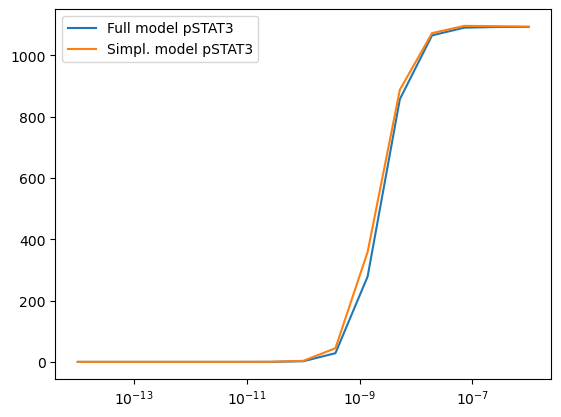

In [14]:
plt.plot(IL10vec,pSTAT3_full, label = "Full model pSTAT3")
plt.plot(IL10vec,pSTAT3_rho, label = "Simpl. model pSTAT3")
plt.xscale("log")
plt.legend(loc="best")

Now we check the behavior of STAT1 and STAT3 signaling among IL10 mutants with increased binding to RB

In [207]:
PA={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00, # OG: 243.95
    "k_DEPHOS_R" : 0.000664996232095083
}

In [208]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_full = []
pSTAT3_full = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_full(PA,IC)
    pSTAT1_full.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA2p_RB2'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1_RA2p_RB2'][-1]+simulator['IL_RA1p_RA2p_RB2'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+simulator['IL_RA2p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_full.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 32.641702 seconds


In [209]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_simpl = []
pSTAT3_simpl = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_simpl(PA,IC)
    # pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_simpl.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 36.877341 seconds


In [210]:
PA_mut={
    "vol_EC" : 1.0E-10, # In dm # OG: 1.0E-10
    "surf_cell" : 1.11545244e-07, # OG: 1.4e-08 Mut_noSOCS: 1.4e-7
    "vol_cell" : 3.0E-12, # In dm
    "k_ILM_f" : 6.97E+05,
    "k_ILM_b" : 3.07214605e+00, #4.34 # OG: 4.34e-02 Mut_noSOCS: 8.34e-02
    "k_IL_RA_f" : 6.97E+05,
    "k_IL_RA_b" : 5.94742574e-04, # OG: 1.42E-04 Mut_noSOCS: 1.42E-03
    "k_IL_RB_f" : 6.97E+05,
    "k_IL_RB_b" : 1394, # OG: 1394
    "k_IL_RA_RB_f" : 6.97E+05,
    "k_IL_RA_RB_b" : 1.32365577e+00/10, # OG: 243.95
    "k_DEPHOS_R" : 0.000664996232095083
}

In [211]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_full_mut = []
pSTAT3_full_mut = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_full(PA_mut,IC)
    pSTAT1_full_mut.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA2p_RB2'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1_RA2p_RB2'][-1]+simulator['IL_RA1p_RA2p_RB2'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+simulator['IL_RA2p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_full_mut.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_simpl_mut = []
pSTAT3_simpl_mut = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    simulator = model_func_simpl(PA_mut,IC)
    # pSTAT1_simpl.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+simulator['IL_RA1p_RB1_RB2'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT1_simpl_mut.append(simulator['IL_RA1p_RB1'][-1]+simulator['IL_RA1p_RA2_RB1'][-1]+simulator['IL_RA1p_RA2p_RB1'][-1]+2*simulator['IL_RA1p_RA2p_RB1_RB2'][-1])
    pSTAT3_simpl_mut.append(simulator['RAp'][-1])
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 31.450109 seconds
Execution Time: 33.488305 seconds


In [226]:
start_time = time()
IL10vec = np.exp(np.linspace(np.log(1e-14), np.log(1e-6), 15))
pSTAT1_rho_mut = []
pSTAT3_rho_mut = []
for IL10 in IL10vec:
    IC = {
        "IL0":IL10,
        "RA0":1100,
        "RB0":900
    }
    pSTAT3,pSTAT1 = simulate_model(PA_mut,IC)
    pSTAT1_rho_mut.append(pSTAT1)
    pSTAT3_rho_mut.append(pSTAT3)
    
end_time = time()  # Record the end time
execution_time = end_time - start_time  # Calculate execution time
print(f"Execution Time: {execution_time:.6f} seconds")

Execution Time: 5.101888 seconds


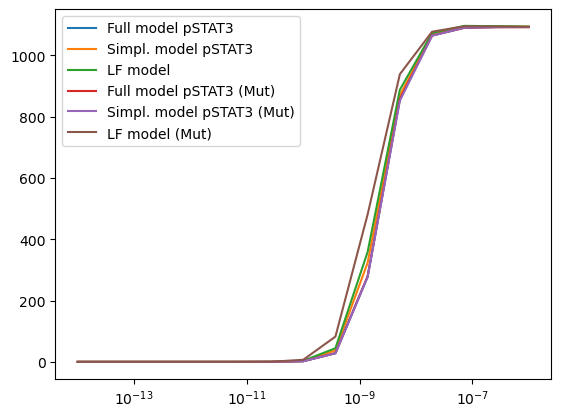

In [227]:
plt.plot(IL10vec,pSTAT3_full, label = "Full model pSTAT3")
plt.plot(IL10vec,pSTAT3_simpl, label = "Simpl. model pSTAT3")
plt.plot(IL10vec,pSTAT3_rho, label = "LF model")
plt.plot(IL10vec,pSTAT3_full_mut, label = "Full model pSTAT3 (Mut)")
plt.plot(IL10vec,pSTAT3_simpl_mut, label = "Simpl. model pSTAT3 (Mut)")
plt.plot(IL10vec,pSTAT3_rho_mut, label = "LF model (Mut)")
plt.xscale("log")
plt.legend(loc="best")

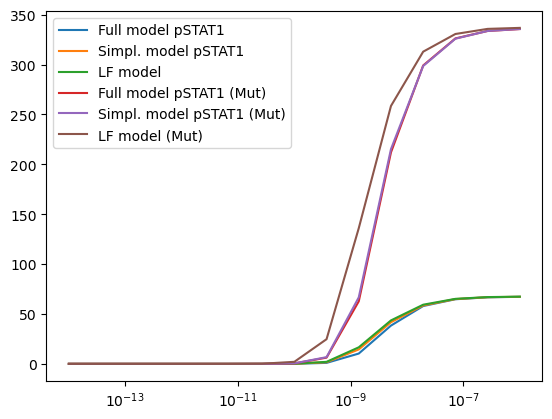

In [228]:
plt.plot(IL10vec,pSTAT1_full, label = "Full model pSTAT1")
plt.plot(IL10vec,pSTAT1_simpl, label = "Simpl. model pSTAT1")
plt.plot(IL10vec,pSTAT1_rho, label = "LF model")
plt.plot(IL10vec,pSTAT1_full_mut, label = "Full model pSTAT1 (Mut)")
plt.plot(IL10vec,pSTAT1_simpl_mut, label = "Simpl. model pSTAT1 (Mut)")
plt.plot(IL10vec,pSTAT1_rho_mut, label = "LF model (Mut)")
plt.xscale("log")
plt.legend(loc="best")